# HDAC8 QSAR models (MACCS)

Regression models for HDAC8 pChEMBL on the scaffold-split sets `HDAC8_train.sdf` and `HDAC8_test.sdf`.

Descriptors: MACCS structural keys (RDKit 167-bit vector; keys 1–166, bit 0 unused). Hyperparameters are tuned with **Optuna** (TPE + median pruning) instead of `GridSearchCV`.


## 1. Imports and settings


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import optuna
from IPython.display import display
import ipywidgets as widgets
from catboost import CatBoostRegressor
from molvs import standardize_smiles
from rdkit import Chem, RDLogger
from rdkit.Chem import MACCSkeys
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, permutation_test_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
ACTIVITY_PROP = "pchembl_value_mean"
TRAIN_SDF = Path("HDAC8_train.sdf")
TEST_SDF = Path("HDAC8_test.sdf")
MODEL_DIR = Path("models/MACCS")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# RDKit MACCS: 167 bits (bit 0 unused; public keys 1-166).
FP_SIZE = 167
AD_Z = 0.5

# Set True for a short debug run.
QUICK_RUN = False
N_SPLITS_SEARCH = 3 if QUICK_RUN else 5
N_TRIALS = {
    "CatBoost": 8 if QUICK_RUN else 40,
    "SVR": 8 if QUICK_RUN else 35,
    "MLP": 6 if QUICK_RUN else 25,
    "kNN": 8 if QUICK_RUN else 25,
}
N_PERMUTATIONS = 5 if QUICK_RUN else 20

cv_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
rng = np.random.RandomState(SEED)


## 2. Data loading and curation

Molecules are sanitized and standardized with MolVS. Failed structures are dropped together with their activity values. The endpoint is `pchembl_value_mean` from the revision SDF files.


In [2]:
def load_sdf(path, activity_prop=ACTIVITY_PROP):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []

    for i, mol in enumerate(supplier):
        rec = {"index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue

        rec["chembl_id"] = mol.GetProp("molecule_chembl_id") if mol.HasProp("molecule_chembl_id") else f"mol_{i+1}"
        rec["smiles_raw"] = (
            mol.GetProp("canonical_smiles") if mol.HasProp("canonical_smiles") else Chem.MolToSmiles(mol)
        )
        rec["scaffold"] = mol.GetProp("scaffold") if mol.HasProp("scaffold") else ""
        try:
            rec["y"] = float(mol.GetProp(activity_prop))
        except Exception as exc:
            failed.append({**rec, "reason": f"missing/invalid {activity_prop}: {exc}"})
            continue

        try:
            Chem.SanitizeMol(mol)
            std_smi = standardize_smiles(Chem.MolToSmiles(mol))
            std_mol = Chem.MolFromSmiles(std_smi)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None after standardization")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue

        rec.update({"mol": std_mol, "smiles": std_smi})
        rows.append(rec)

    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


train_df, train_failed = load_sdf(TRAIN_SDF)
test_df, test_failed = load_sdf(TEST_SDF)

display(train_failed if len(train_failed) else "No failed training molecules")
display(test_failed if len(test_failed) else "No failed test molecules")


HDAC8_train.sdf: kept 2092 / 2092 molecules (0 failed)
HDAC8_test.sdf: kept 524 / 524 molecules (0 failed)


'No failed training molecules'

'No failed test molecules'

Train: n = 2092, pChEMBL = 6.049 ± 0.883 [4.02, 9.92], scaffolds = 1
Test: n = 524, pChEMBL = 6.051 ± 0.895 [4.01, 9.99], scaffolds = 1
Shared Murcko scaffolds: 0


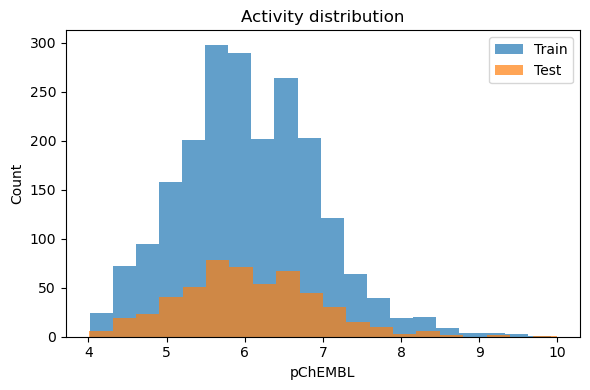

,index,chembl_id,smiles_raw,scaffold,y,mol,smiles
0,1,CHEMBL1767046,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...,,4.02,<rdkit.Chem.rdchem.Mol object at 0x000001509ED...,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...
1,2,CHEMBL1469,O=C(O)CCCc1ccccc1,,4.03,<rdkit.Chem.rdchem.Mol object at 0x000001509ED...,O=C(O)CCCc1ccccc1
2,3,CHEMBL3605493,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x000001509ED...,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...
3,4,CHEMBL1767047,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x000001509ED...,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...
4,5,CHEMBL3605499,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...,,4.08,<rdkit.Chem.rdchem.Mol object at 0x000001509ED...,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...


In [3]:
def summarize_split(name, df):
    print(
        f"{name}: n = {len(df)}, "
        f"pChEMBL = {df['y'].mean():.3f} ± {df['y'].std():.3f} "
        f"[{df['y'].min():.2f}, {df['y'].max():.2f}], "
        f"scaffolds = {df['scaffold'].nunique()}"
    )


summarize_split("Train", train_df)
summarize_split("Test", test_df)

shared = set(train_df["scaffold"]) & set(test_df["scaffold"])
shared.discard("")
print("Shared Murcko scaffolds:", len(shared))
if shared:
    raise AssertionError("Scaffold leakage between train and test.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(train_df["y"], bins=20, alpha=0.7, label="Train")
ax.hist(test_df["y"], bins=20, alpha=0.7, label="Test")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Count")
ax.set_title("Activity distribution")
ax.legend()
plt.tight_layout()
plt.show()

train_df.head()


## 3. MACCS fingerprints

MACCS structural keys via RDKit `MACCSkeys.GenMACCSKeys`. The vector has 167 bits (keys 1–166 plus unused bit 0). The same function is used for train and test.


In [4]:
def fingerprints(mols):
    return np.vstack([np.asarray(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32) for mol in mols])


X_tr = fingerprints(train_df["mol"])
X_ts = fingerprints(test_df["mol"])
y_tr = train_df["y"].to_numpy(dtype=np.float64)
y_ts = test_df["y"].to_numpy(dtype=np.float64)

if X_tr.shape[1] != FP_SIZE or X_ts.shape[1] != FP_SIZE:
    raise ValueError(f"Expected {FP_SIZE} MACCS bits, got train {X_tr.shape} / test {X_ts.shape}")

print("X_train:", X_tr.shape, "X_test:", X_ts.shape)
print("Mean on-bits / molecule: train {:.1f}, test {:.1f}".format(X_tr.sum(1).mean(), X_ts.sum(1).mean()))

np.savetxt(MODEL_DIR / "x_tr_MACCS.csv", X_tr, delimiter=",")
np.savetxt(MODEL_DIR / "x_ts_MACCS.csv", X_ts, delimiter=",")
np.savetxt(MODEL_DIR / "y_tr.csv", y_tr, delimiter=",")
np.savetxt(MODEL_DIR / "y_ts.csv", y_ts, delimiter=",")


X_train: (2092, 167) X_test: (524, 167)
Mean on-bits / molecule: train 54.5, test 53.7


## 4. Shared utilities

OECD-style metrics: R² on the training set, Q² from cross-validation, and external R² on the held-out scaffold test set.

**Applicability domain (AD).** MACCS bits are binary. Euclidean distance treats shared *off*-bits as similarity and is not the usual comparison for structural keys. The chemically appropriate metric is the Tanimoto (Jaccard) coefficient on on-bits, reported as a distance:

$$D_{\mathrm{Tanimoto}}(a,b) = 1 - T_c(a,b) = 1 - \frac{|A \cap B|}{|A \cup B|}$$

The AD threshold is $\bar{d} + 0.5\,\sigma$ of the nearest-neighbour $D_{\mathrm{Tanimoto}}$ values in the training set (k = 1). A query is inside the domain if its nearest training neighbour satisfies $D_{\mathrm{Tanimoto}} \le d_{\mathrm{limit}}$.

In-AD membership only means the compound is similar to the training fingerprint space. It is **not** proof that an individual prediction is reliable: in-AD compounds can still be mispredicted, and AD-filtered statistics describe the interpolative subset only.

Test-set predictions are appended to `models/MACCS/test_predictions.csv` immediately after each model is evaluated.


In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_t, mean_p = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    return float(2 * cov / denom) if denom else np.nan


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "CCC": ccc(y_true, y_pred),
    }


def tanimoto_distance(X, Y=None):
    """Pairwise D_Tanimoto = 1 - T_c for binary fingerprints.

    T_c(a, b) = |A ∩ B| / |A ∪ B|. Two all-zero vectors are treated as identical (T_c = 1).
    For binary vectors this is the Jaccard distance.
    """
    X = np.asarray(X, dtype=np.float64)
    Y = X if Y is None else np.asarray(Y, dtype=np.float64)
    intersection = X @ Y.T
    x_pop = X.sum(axis=1, keepdims=True)
    y_pop = Y.sum(axis=1, keepdims=True)
    union = x_pop + y_pop.T - intersection
    tc = np.divide(intersection, union, out=np.ones_like(intersection), where=union > 0)
    return 1.0 - tc


def compute_ad(X_train, z=AD_Z):
    dist = tanimoto_distance(X_train)
    np.fill_diagonal(dist, np.inf)
    nn = dist.min(axis=1)
    limit = float(nn.mean() + z * nn.std(ddof=0))
    return limit, nn


def apply_ad(X_train, X_test, limit):
    dist = tanimoto_distance(X_test, X_train)
    nn = dist.min(axis=1)
    return nn <= limit, nn


def plot_obs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.scatter(y_true, y_pred, s=16, alpha=0.65, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], color="black", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed pChEMBL")
    ax.set_ylabel("Predicted pChEMBL")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax


def cv_r2_pruned(trial, factory, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for step, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        model = factory()
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


def run_study(name, objective, n_trials):
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=name)

    # Optuna's tqdm.notebook bar often fails in Jupyter Notebook 7
    # ("Error displaying widget: model not found"). Use core ipywidgets instead.
    bar = widgets.IntProgress(value=0, min=0, max=n_trials, description=name, bar_style="info")
    label = widgets.HTML(value="starting&hellip;")
    display(widgets.HBox([bar, label]))

    def on_trial(study, trial):
        bar.value = len(study.trials)
        if trial.state.name == "PRUNED":
            label.value = f"trial {trial.number} pruned; best CV R² = {study.best_value:.4f}"
        elif trial.value is not None:
            label.value = (
                f"trial {trial.number}: CV R² = {trial.value:.4f}; "
                f"best = {study.best_value:.4f} (trial {study.best_trial.number})"
            )
        if bar.value >= n_trials:
            bar.bar_style = "success"

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[on_trial])
    print(f"{name}: best CV R2 = {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


def evaluate_model(name, estimator, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=None, cv_fit_params=None):
    fit_params = fit_params or {}
    cv_fit_params = cv_fit_params or {}
    model = clone(estimator)
    model.fit(X_tr, y_tr, **fit_params)

    y_hat_tr = model.predict(X_tr)
    y_hat_cv = cross_val_predict(clone(estimator), X_tr, y_tr, cv=cv_final, n_jobs=1, params=cv_fit_params)
    y_hat_ts = model.predict(X_ts)

    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)

    coverage = float(in_ad.mean()) if len(in_ad) else np.nan
    if in_ad.any():
        ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad])
    else:
        ad_m = {k: np.nan for k in test_m}

    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": coverage,
    }

    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    if (~in_ad).any():
        axes[2].scatter(
            y_ts[~in_ad],
            y_hat_ts[~in_ad],
            s=28,
            facecolors="none",
            edgecolors="crimson",
            label="outside training space (AD)",
        )
        axes[2].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return model, row, {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}


def write_test_predictions(name, y_hat_ts):
    pred_table[f"pred_{name}"] = np.asarray(y_hat_ts)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Updated {MODEL_DIR / 'test_predictions.csv'} with pred_{name}")
    cols = ["chembl_id", "pchembl_obs", f"pred_{name}", "in_AD", "D_Tanimoto", "T_c"]
    display(pred_table[cols].head())


results = []
fitted = {}
preds = {}
studies = {}


Train NN D_Tanimoto: 0.066 ± 0.074
AD limit (mean + 0.5*SD): 0.104
Test compounds similar to training space: 0.761 (399/524)
in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.


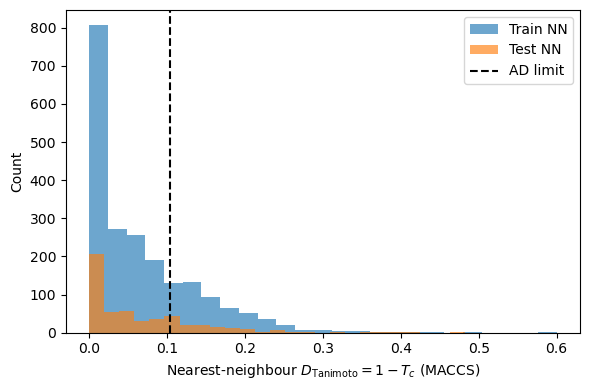

In [6]:
ad_limit, nn_train = compute_ad(X_tr)
in_ad, nn_test = apply_ad(X_tr, X_ts, ad_limit)

pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
pred_table["in_AD"] = in_ad
pred_table["D_Tanimoto"] = nn_test
pred_table["T_c"] = 1.0 - nn_test
pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

print(f"Train NN D_Tanimoto: {nn_train.mean():.3f} ± {nn_train.std():.3f}")
print(f"AD limit (mean + {AD_Z}*SD): {ad_limit:.3f}")
print(f"Test compounds similar to training space: {in_ad.mean():.3f} ({in_ad.sum()}/{len(in_ad)})")
print("in-AD = nearest-neighbour Tanimoto similarity to the training set, not a reliability certificate.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nn_train, bins=25, alpha=0.65, label="Train NN")
ax.hist(nn_test, bins=25, alpha=0.65, label="Test NN")
ax.axvline(ad_limit, color="black", ls="--", label="AD limit")
ax.set_xlabel(r"Nearest-neighbour $D_{\mathrm{Tanimoto}} = 1 - T_c$ (MACCS)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. CatBoost

Trees do not need scaling. Search space covers depth, learning rate, L2, leaf size and boosting rounds. Each trial is scored by mean 5-fold R² with median pruning.


CatBoost: best CV R2 = 0.5556
Best params: {'depth': 9, 'learning_rate': 0.04407263643380197, 'l2_leaf_reg': 2.6617821723536226, 'min_data_in_leaf': 16, 'iterations': 800}
model          CatBoost
R2_train       0.928638
RMSE_train     0.235785
Q2_CV          0.556855
RMSE_CV        0.587563
MAE_CV         0.428278
R2_ext         0.611328
RMSE_ext       0.557451
MAE_ext        0.420364
CCC_ext        0.759235
R2_ext_AD      0.710272
RMSE_ext_AD    0.493473
AD_coverage     0.76145


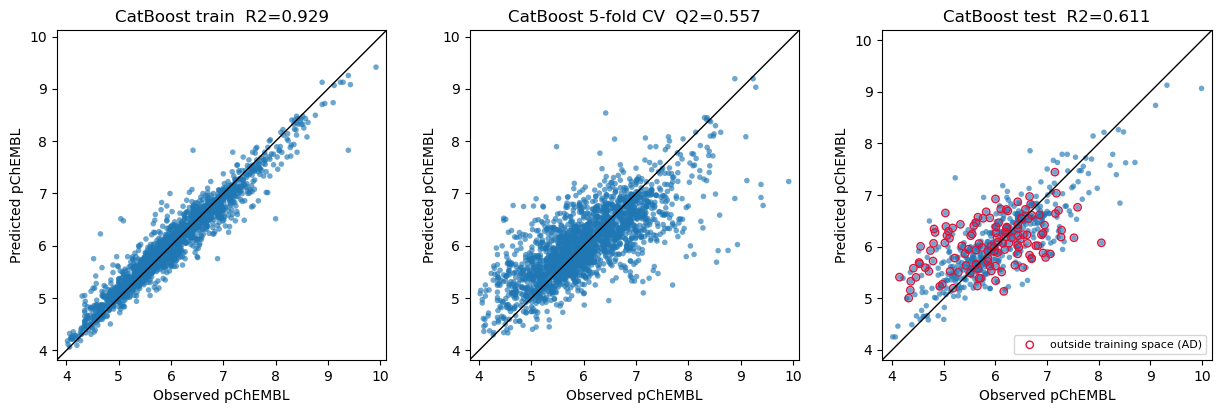

Updated models\MACCS\test_predictions.csv with pred_CatBoost


,chembl_id,pchembl_obs,pred_CatBoost,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.252867,True,0.054054,0.945946
1,CHEMBL3605494,4.06,4.250269,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.460076,True,0.057143,0.942857
3,CHEMBL5571764,4.14,5.409800,False,0.140000,0.860000
4,CHEMBL3771210,4.21,5.389737,True,0.048780,0.951220


['models\\MACCS\\CatBoost_MACCS.pkl']

In [7]:
def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
        "iterations": trial.suggest_int("iterations", 200, 1000, step=100),
        "random_seed": SEED,
        "verbose": False,
        "loss_function": "RMSE",
        "allow_writing_files": False,
    }
    return cv_r2_pruned(trial, lambda: CatBoostRegressor(**params), X_tr, y_tr, cv_search)


studies["CatBoost"] = run_study("CatBoost", objective_catboost, N_TRIALS["CatBoost"])
best_cat = CatBoostRegressor(
    **studies["CatBoost"].best_params,
    random_seed=SEED,
    verbose=False,
    loss_function="RMSE",
    allow_writing_files=False,
)
cat_fit = {"verbose": False}
fitted["CatBoost"], row, preds["CatBoost"] = evaluate_model(
    "CatBoost", best_cat, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=cat_fit, cv_fit_params=cat_fit
)
results.append(row)
joblib.dump(fitted["CatBoost"], MODEL_DIR / "CatBoost_MACCS.pkl")


## 6. Support vector regression

RBF-SVR inside a `Pipeline` with `StandardScaler`, so scaling is fit only on each CV training fold. `C`, `gamma` and `epsilon` are searched on a log/linear scale covering the old grid and intermediate values.


SVR: best CV R2 = 0.5316
Best params: {'C': 1.8019295124548669, 'gamma': 0.014331663641893633, 'epsilon': 0.10997475853891327}
model               SVR
R2_train       0.890022
RMSE_train     0.292708
Q2_CV          0.532748
RMSE_CV        0.603333
MAE_CV         0.438757
R2_ext         0.580375
RMSE_ext       0.579222
MAE_ext        0.430379
CCC_ext        0.729844
R2_ext_AD      0.677087
RMSE_ext_AD    0.520969
AD_coverage     0.76145


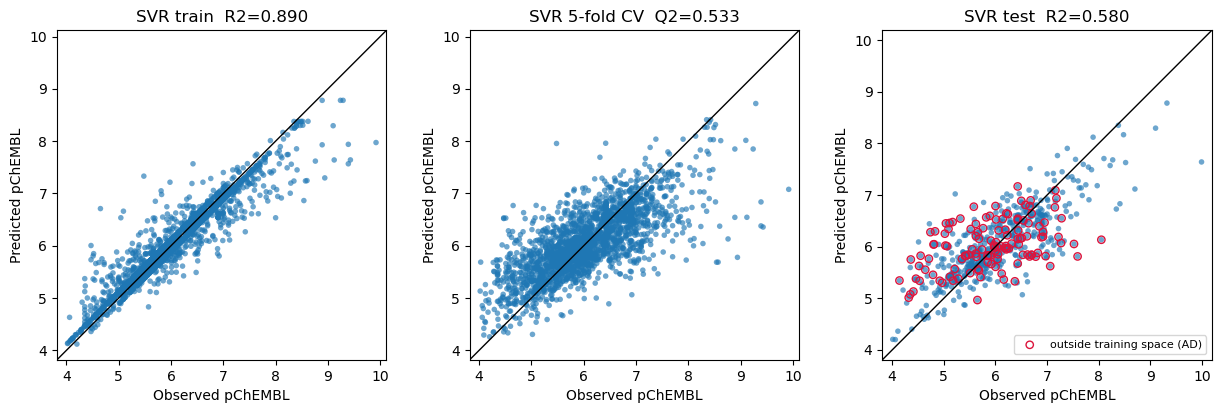

Updated models\MACCS\test_predictions.csv with pred_SVR


,chembl_id,pchembl_obs,pred_SVR,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.204690,True,0.054054,0.945946
1,CHEMBL3605494,4.06,4.200210,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.362340,True,0.057143,0.942857
3,CHEMBL5571764,4.14,5.343777,False,0.140000,0.860000
4,CHEMBL3771210,4.21,5.158454,True,0.048780,0.951220


['models\\MACCS\\SVM_MACCS.pkl']

In [8]:
def make_svr(C, gamma, epsilon):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon, cache_size=500)),
        ]
    )


def objective_svr(trial):
    C = trial.suggest_float("C", 0.1, 1e4, log=True)
    gamma = trial.suggest_float("gamma", 1e-6, 1e-1, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 0.5)
    return cv_r2_pruned(trial, lambda: make_svr(C, gamma, epsilon), X_tr, y_tr, cv_search)


studies["SVR"] = run_study("SVR", objective_svr, N_TRIALS["SVR"])
best_svr = make_svr(**studies["SVR"].best_params)
fitted["SVR"], row, preds["SVR"] = evaluate_model("SVR", best_svr, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["SVR"], MODEL_DIR / "SVM_MACCS.pkl")


## 7. Multi-layer perceptron

The previous grid mixed oversized networks (`(400, 300, 200, 100)`) with `lbfgs`/`sgd` and was oversized even for the compact ~2k × 167 MACCS matrix. Search is limited to 1–3 hidden layers, Adam, L2 and learning rate, with early stopping.


MLP: best CV R2 = 0.3969
Best params: {'n_layers': 2, 'n_units': 256, 'activation': 'relu', 'alpha': 2.9380279387035334e-05, 'learning_rate_init': 0.00020511104188433984}
model               MLP
R2_train       0.858721
RMSE_train     0.331757
Q2_CV          0.399854
RMSE_CV         0.68377
MAE_CV         0.501748
R2_ext         0.486142
RMSE_ext       0.640968
MAE_ext        0.480908
CCC_ext        0.700572
R2_ext_AD      0.631541
RMSE_ext_AD    0.556498
AD_coverage     0.76145


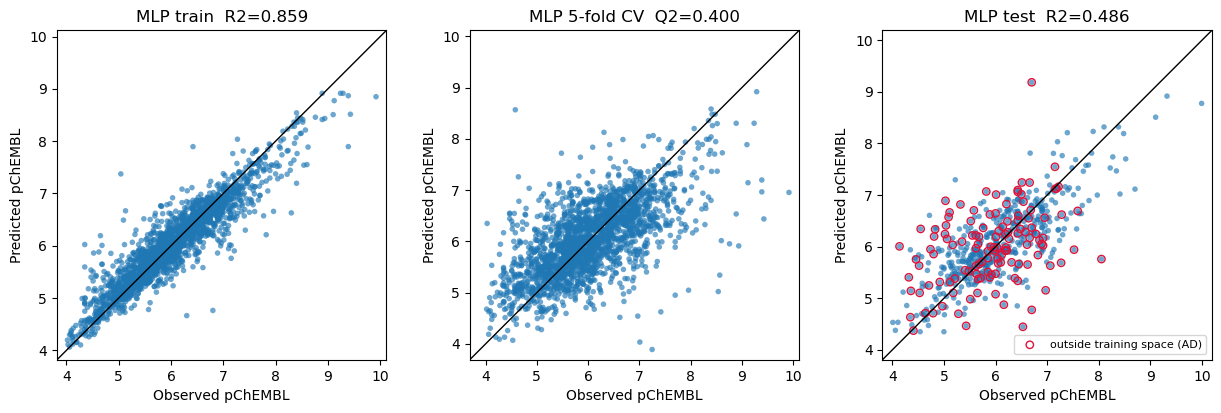

Updated models\MACCS\test_predictions.csv with pred_MLP


,chembl_id,pchembl_obs,pred_MLP,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.532374,True,0.054054,0.945946
1,CHEMBL3605494,4.06,4.378984,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.534993,True,0.057143,0.942857
3,CHEMBL5571764,4.14,6.005309,False,0.140000,0.860000
4,CHEMBL3771210,4.21,5.119326,True,0.048780,0.951220


['models\\MACCS\\MLPR_MACCS.pkl']

In [9]:
def make_mlp(n_layers, n_units, activation, alpha, learning_rate_init):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=tuple([n_units] * n_layers),
                    activation=activation,
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    solver="adam",
                    max_iter=400,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=15,
                    random_state=SEED,
                ),
            ),
        ]
    )


def objective_mlp(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units = trial.suggest_int("n_units", 32, 256, step=32)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    lr = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    return cv_r2_pruned(
        trial, lambda: make_mlp(n_layers, n_units, activation, alpha, lr), X_tr, y_tr, cv_search
    )


studies["MLP"] = run_study("MLP", objective_mlp, N_TRIALS["MLP"])
best_mlp = make_mlp(**studies["MLP"].best_params)
fitted["MLP"], row, preds["MLP"] = evaluate_model("MLP", best_mlp, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["MLP"], MODEL_DIR / "MLPR_MACCS.pkl")


## 8. k-nearest neighbors

`n_neighbors`, `weights` and distance metric are optimized. Jaccard (Tanimoto distance on binary bits) is included because it is more appropriate for MACCS keys than Euclidean-only search. The old notebook also overwrote `x_ts` with training fingerprints; predictions now always use `X_ts`.


kNN: best CV R2 = 0.5062
Best params: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'cosine'}
model               kNN
R2_train       0.962111
RMSE_train     0.171805
Q2_CV          0.507512
RMSE_CV        0.619412
MAE_CV         0.444336
R2_ext         0.599041
RMSE_ext       0.566193
MAE_ext        0.414761
CCC_ext        0.767732
R2_ext_AD      0.681109
RMSE_ext_AD    0.517714
AD_coverage     0.76145


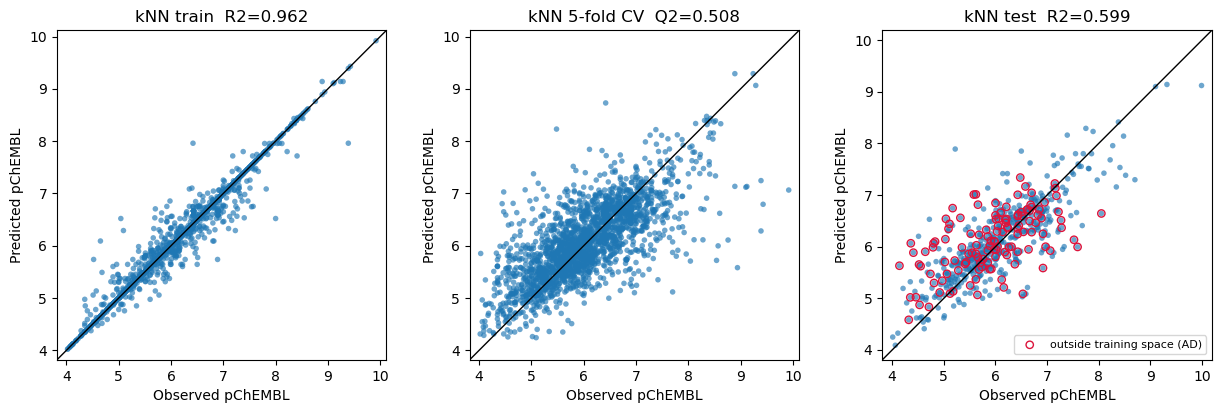

Updated models\MACCS\test_predictions.csv with pred_kNN


,chembl_id,pchembl_obs,pred_kNN,in_AD,D_Tanimoto,T_c
0,CHEMBL5429446,4.01,4.248887,True,0.054054,0.945946
1,CHEMBL3605494,4.06,4.090014,True,0.000000,1.000000
2,CHEMBL5419832,4.11,4.324463,True,0.057143,0.942857
3,CHEMBL5571764,4.14,5.630292,False,0.140000,0.860000
4,CHEMBL3771210,4.21,5.190841,True,0.048780,0.951220


['models\\MACCS\\kNN_MACCS.pkl']

In [10]:
def make_knn(n_neighbors, weights, metric):
    return KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, metric=metric, n_jobs=-1)


def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 31)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "jaccard", "cosine"])
    return cv_r2_pruned(trial, lambda: make_knn(n_neighbors, weights, metric), X_tr, y_tr, cv_search)


studies["kNN"] = run_study("kNN", objective_knn, N_TRIALS["kNN"])
best_knn = make_knn(**studies["kNN"].best_params)
fitted["kNN"], row, preds["kNN"] = evaluate_model("kNN", best_knn, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["kNN"], MODEL_DIR / "kNN_MACCS.pkl")


## 9. Model comparison

Metrics are rounded to two decimals to match the manuscript table: training R²/RMSE, 5-fold Q²cv/RMSE, external Q²test/RMSE (all test compounds), AD coverage (Cov), Q²test/RMSE for compounds inside the applicability domain, and a Tropsha-style validity flag (`valid_tropsha`: Q² > 0.5, R²_ext > 0.6, |R²_ext − Q²| < 0.3).

If the notebook kernel was restarted, metrics are loaded from `models/MACCS/metrics_summary.csv` so models do not need to be retrained.


Loaded cached metrics from models\MACCS\metrics_summary.csv


,R2,RMSE,Q2cv,RMSE,Q2test,RMSE,Cov,Q2test,RMSE,valid_tropsha
model,,,,,,,,,,
CatBoost,0.93,0.24,0.56,0.59,0.61,0.56,0.76,0.71,0.49,True
SVM,0.89,0.29,0.53,0.60,0.58,0.58,0.76,0.68,0.52,False
MLP,0.86,0.33,0.40,0.68,0.49,0.64,0.76,0.63,0.56,False
kNN,0.96,0.17,0.51,0.62,0.60,0.57,0.76,0.68,0.52,False


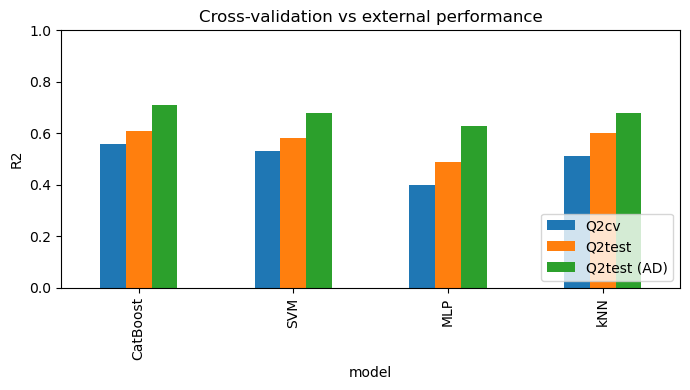

Best single model by external R2: CatBoost


In [ ]:
metrics_path = MODEL_DIR / "metrics_summary.csv"

if "results" in globals() and results:
    summary = pd.DataFrame(results).set_index("model")
elif metrics_path.is_file():
    summary = pd.read_csv(metrics_path, index_col="model")
    print(f"Loaded cached metrics from {metrics_path}")
else:
    raise RuntimeError("No metrics in memory and no cached metrics_summary.csv found.")

summary = summary.drop(index=["Consensus"], errors="ignore")
summary["valid_tropsha"] = (
    (summary["Q2_CV"] > 0.5)
    & (summary["R2_ext"] > 0.6)
    & ((summary["R2_ext"] - summary["Q2_CV"]).abs() < 0.3)
)

TABLE_COLS = [
    "R2_train",
    "RMSE_train",
    "Q2_CV",
    "RMSE_CV",
    "R2_ext",
    "RMSE_ext",
    "AD_coverage",
    "R2_ext_AD",
    "RMSE_ext_AD",
]
TABLE_HEADERS = [
    "R2",
    "RMSE",
    "Q2cv",
    "RMSE",
    "Q2test",
    "RMSE",
    "Cov",
    "Q2test",
    "RMSE",
]
DISPLAY_NAMES = {"SVR": "SVM"}

table = summary[TABLE_COLS].copy()
table.index = table.index.map(lambda name: DISPLAY_NAMES.get(name, name))
table.columns = TABLE_HEADERS
table = table.round(2)
table["valid_tropsha"] = summary["valid_tropsha"].values

display(table)

fig, ax = plt.subplots(figsize=(7, 4))
summary[["Q2_CV", "R2_ext", "R2_ext_AD"]].round(2).rename(
    index=DISPLAY_NAMES,
    columns={"Q2_CV": "Q2cv", "R2_ext": "Q2test", "R2_ext_AD": "Q2test (AD)"},
).plot(kind="bar", ax=ax)
ax.set_ylabel("R2")
ax.set_ylim(0, 1)
ax.set_title("Cross-validation vs external performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = summary["R2_ext"].idxmax()
print("Best single model by external R2:", DISPLAY_NAMES.get(best_name, best_name))

table.to_csv(metrics_path)
if "studies" in globals() and studies:
    joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
    joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")


## 10. Y-randomization

`permutation_test_score` shuffles the training endpoint and repeats CV. A real structure–activity relationship should give a high true Q² and a near-zero (or negative) mean randomized score with a small p-value.


In [13]:
y_rand_rows = []
for name, est in fitted.items():
    perm_kwargs = {}
    if name == "CatBoost":
        perm_kwargs["params"] = {"verbose": False}
    score, perm_scores, pvalue = permutation_test_score(
        clone(est),
        X_tr,
        y_tr,
        cv=cv_final,
        scoring="r2",
        n_permutations=N_PERMUTATIONS,
        n_jobs=1 if name == "CatBoost" else -1,
        random_state=SEED,
        **perm_kwargs,
    )
    y_rand_rows.append(
        {
            "model": name,
            "true_Q2": score,
            "y_rand_mean": float(np.mean(perm_scores)),
            "y_rand_std": float(np.std(perm_scores)),
            "p_value": float(pvalue),
        }
    )
    print(
        f"{name}: true Q2 = {score:.3f}, "
        f"Y-randomization = {np.mean(perm_scores):.3f} ± {np.std(perm_scores):.3f}, "
        f"p = {pvalue:.4f}"
    )

y_rand = pd.DataFrame(y_rand_rows).set_index("model")
display(y_rand.round(4))
y_rand.round(4).to_csv(MODEL_DIR / "y_randomization.csv")


CatBoost: true Q2 = 0.556, Y-randomization = -0.260 ± 0.020, p = 0.0476
SVR: true Q2 = 0.532, Y-randomization = -0.211 ± 0.020, p = 0.0476
MLP: true Q2 = 0.397, Y-randomization = -0.230 ± 0.019, p = 0.0476
kNN: true Q2 = 0.506, Y-randomization = -0.344 ± 0.029, p = 0.0476


,true_Q2,y_rand_mean,y_rand_std,p_value
model,,,,
CatBoost,0.5556,-0.2600,0.0196,0.0476
SVR,0.5316,-0.2109,0.0196,0.0476
MLP,0.3969,-0.2300,0.0193,0.0476
kNN,0.5062,-0.3439,0.0294,0.0476
